# 04. Final Dataset Preparation (Train + External Valid → GPU Package)

## 목표
1. 외부 검증셋(valid_maturity.csv, valid_quality.csv)을 학습셋(train.csv)과 **동일한 컬럼 스키마**로 정렬
2. **Train vs Valid 비교 분석** (클래스 분포 / 해상도 / RGB 통계 / 파일 크기) — 도메인 일치성 검증
3. **최종 데이터셋 패키지** 생성 — GPU 서버로 전송 가능한 자기완결적 구조
4. (선택) zip 압축으로 패키징

## 산출물
```
package/                              ← GPU 서버로 옮길 폴더
├── images/
│   ├── train/{task}/{type}/{class}/  ← 10,000장
│   └── valid/                        ← 1,559장 (unique by hash)
├── manifest/
│   ├── train.csv
│   ├── valid_maturity.csv
│   └── valid_quality.csv
├── meta.json
└── README.md
```

## 1. 환경 설정

In [1]:
import json
import shutil
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm.notebook import tqdm

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR    = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR     = PROJECT_ROOT / 'results' / 'tables'
PACKAGE_DIR    = PROJECT_ROOT / 'package'   # ← GPU 서버로 옮길 디렉토리

for d in [RESULTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('OK')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'PACKAGE_DIR:  {PACKAGE_DIR}')

OK
PROJECT_ROOT: C:\Users\smin\IdeaProjects\tomato
PACKAGE_DIR:  C:\Users\smin\IdeaProjects\tomato\package


## 2. 기존 CSV 로드

In [2]:
train_df = pd.read_csv(DATA_PROCESSED / 'train.csv')
val_mat  = pd.read_csv(DATA_PROCESSED / 'valid_maturity.csv')
val_qual = pd.read_csv(DATA_PROCESSED / 'valid_quality.csv')

print(f'train.csv:          {len(train_df):>6,} rows   columns={list(train_df.columns)}')
print(f'valid_maturity.csv: {len(val_mat):>6,} rows   columns={list(val_mat.columns)}')
print(f'valid_quality.csv:  {len(val_qual):>6,} rows   columns={list(val_qual.columns)}')

train.csv:          10,000 rows   columns=['filepath', 'task', 'dataset_type', 'class_label', 'filename', 'is_augmented', 'original_basename']
valid_maturity.csv:    890 rows   columns=['content_hash', 'rep_filepath', 'rep_filename', 'class_label', 'n_duplicates', 'buckets_present', 'task']
valid_quality.csv:   1,556 rows   columns=['content_hash', 'rep_filepath', 'rep_filename', 'class_label', 'n_duplicates', 'buckets_present', 'task']


## 3. 스키마 정렬 (Schema Alignment)

학습셋과 검증셋의 컬럼을 일치시킨다. 통합된 스키마:

| 컬럼 | 설명 |
|---|---|
| `filepath` | 절대 경로 (이후 상대 경로로 변환) |
| `task` | maturity / quality |
| `dataset_type` | original / augment / external_valid |
| `class_label` | immature / mature / fresh / rotten |
| `filename` | 파일명 |
| `is_augmented` | bool |
| `original_basename` | 원본 파일명 추적 (group key, train만 유효) |
| `split` | train / valid |
| `content_hash` | MD5 (valid만, train은 NaN) |

In [3]:
def align_train(df):
    out = df.copy()
    out['split'] = 'train'
    out['content_hash'] = None
    # class_label은 이미 소문자 (immature/mature/fresh/rotten)
    return out[['filepath', 'task', 'dataset_type', 'class_label',
                'filename', 'is_augmented', 'original_basename', 'split', 'content_hash']]

def align_valid(df):
    out = df.copy()
    out = out.rename(columns={'rep_filepath': 'filepath', 'rep_filename': 'filename'})
    out['dataset_type'] = 'external_valid'
    out['is_augmented'] = False
    out['original_basename'] = out['filename']
    out['split'] = 'valid'
    # class_label은 Mature/Immature/Fresh/Rotten → 소문자로 통일
    out['class_label'] = out['class_label'].str.lower()
    return out[['filepath', 'task', 'dataset_type', 'class_label',
                'filename', 'is_augmented', 'original_basename', 'split', 'content_hash']]

train_aligned = align_train(train_df)
val_mat_aligned  = align_valid(val_mat)
val_qual_aligned = align_valid(val_qual)

print('=== 스키마 정렬 후 ===')
for name, d in [('train', train_aligned), ('val_mat', val_mat_aligned), ('val_qual', val_qual_aligned)]:
    print(f'{name:10s}  rows={len(d):>6,}  columns={list(d.columns)}')

# 검증
assert list(train_aligned.columns) == list(val_mat_aligned.columns) == list(val_qual_aligned.columns)
print('\n✅ 모든 CSV 컬럼 일치')

=== 스키마 정렬 후 ===
train       rows=10,000  columns=['filepath', 'task', 'dataset_type', 'class_label', 'filename', 'is_augmented', 'original_basename', 'split', 'content_hash']
val_mat     rows=   890  columns=['filepath', 'task', 'dataset_type', 'class_label', 'filename', 'is_augmented', 'original_basename', 'split', 'content_hash']
val_qual    rows= 1,556  columns=['filepath', 'task', 'dataset_type', 'class_label', 'filename', 'is_augmented', 'original_basename', 'split', 'content_hash']

✅ 모든 CSV 컬럼 일치


## 4. Train vs Valid 비교: 클래스 분포

학습과 평가의 클래스 분포가 어떻게 다른지 확인.

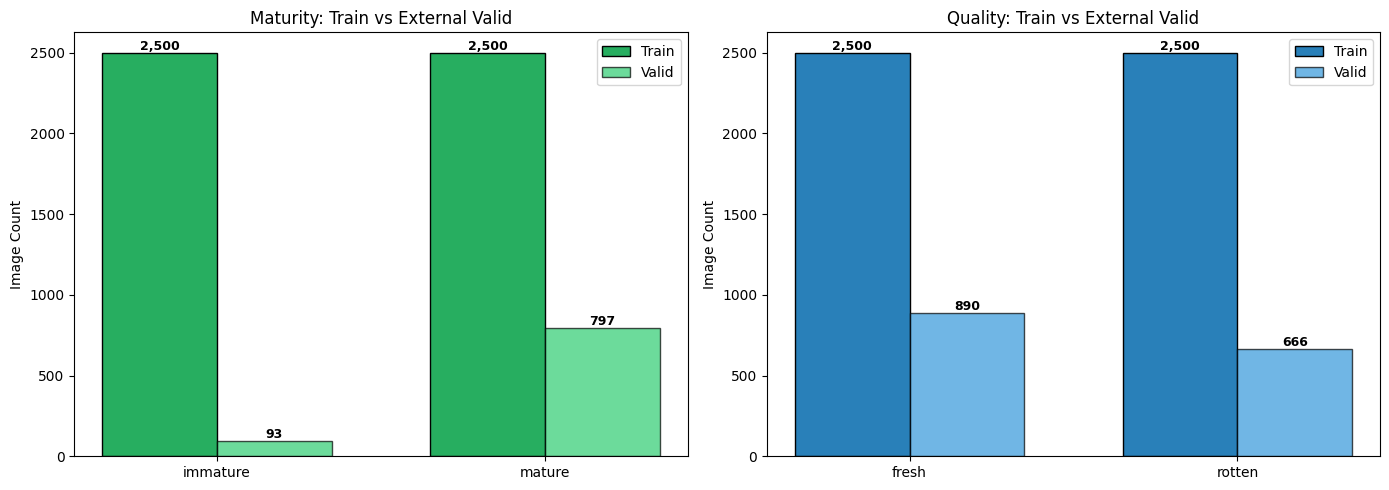

=== 클래스 비율 ===
Train Maturity: {'immature': '2500 (50.0%)', 'mature': '2500 (50.0%)'}
Valid Maturity: {'immature': '93 (10.4%)', 'mature': '797 (89.6%)'}
Train Quality:  {'fresh': '2500 (50.0%)', 'rotten': '2500 (50.0%)'}
Valid Quality:  {'fresh': '890 (57.2%)', 'rotten': '666 (42.8%)'}


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Maturity
ax = axes[0]
train_mat = train_aligned[train_aligned['task'] == 'maturity']['class_label'].value_counts()
val_mat_c  = val_mat_aligned['class_label'].value_counts()

x = np.arange(2)
width = 0.35
classes_m = ['immature', 'mature']
train_vals = [train_mat.get(c, 0) for c in classes_m]
val_vals   = [val_mat_c.get(c, 0)  for c in classes_m]

b1 = ax.bar(x - width/2, train_vals, width, color='#27ae60', label='Train', edgecolor='black')
b2 = ax.bar(x + width/2, val_vals,   width, color='#2ecc71', label='Valid', edgecolor='black', alpha=0.7)
for bar, v in list(zip(b1, train_vals)) + list(zip(b2, val_vals)):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'{int(v):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(classes_m)
ax.set_title('Maturity: Train vs External Valid')
ax.set_ylabel('Image Count'); ax.legend()

# Quality
ax = axes[1]
train_qual_c = train_aligned[train_aligned['task'] == 'quality']['class_label'].value_counts()
val_qual_c    = val_qual_aligned['class_label'].value_counts()

classes_q = ['fresh', 'rotten']
train_vals = [train_qual_c.get(c, 0) for c in classes_q]
val_vals   = [val_qual_c.get(c, 0)   for c in classes_q]

b1 = ax.bar(x - width/2, train_vals, width, color='#2980b9', label='Train', edgecolor='black')
b2 = ax.bar(x + width/2, val_vals,   width, color='#3498db', label='Valid', edgecolor='black', alpha=0.7)
for bar, v in list(zip(b1, train_vals)) + list(zip(b2, val_vals)):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'{int(v):,}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(classes_q)
ax.set_title('Quality: Train vs External Valid')
ax.set_ylabel('Image Count'); ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / '10_train_vs_valid_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== 클래스 비율 ===')
def ratio(d, classes):
    counts = [d[d['class_label']==c].shape[0] for c in classes]
    total = sum(counts)
    return {c: f'{n} ({n/total*100:.1f}%)' for c, n in zip(classes, counts)}

print('Train Maturity:', ratio(train_aligned[train_aligned.task=='maturity'], classes_m))
print('Valid Maturity:', ratio(val_mat_aligned, classes_m))
print('Train Quality: ', ratio(train_aligned[train_aligned.task=='quality'], classes_q))
print('Valid Quality: ', ratio(val_qual_aligned, classes_q))

## 5. Train vs Valid 비교: 이미지 속성

해상도 / 파일 크기를 train 샘플(클래스당 100장)과 valid 전체에서 측정 후 비교.

In [5]:
def extract_meta(filepath):
    try:
        with Image.open(filepath) as img:
            w, h = img.size
        size_kb = Path(filepath).stat().st_size / 1024
        return w, h, size_kb
    except Exception:
        return None, None, None

def sample_meta(df, n_per_class=100):
    records = []
    for (task, cls), g in df.groupby(['task', 'class_label']):
        n = len(g) if n_per_class is None else min(n_per_class, len(g))
        sub = g.sample(n=n, random_state=SEED)
        for _, r in sub.iterrows():
            w, h, sz = extract_meta(r['filepath'])
            records.append({'task': task, 'class_label': cls, 'width': w, 'height': h, 'size_kb': sz})
    return pd.DataFrame(records)

print('Train 메타 추출 중...')
train_meta = sample_meta(train_aligned, n_per_class=100)

print('Valid Maturity 메타 추출 중...')
val_mat_meta = sample_meta(val_mat_aligned, n_per_class=None)  # 전체 사용 (890장)

print('Valid Quality 메타 추출 중...')
val_qual_meta = sample_meta(val_qual_aligned, n_per_class=300)

print()
print('=== 해상도 통계 ===')
def stats(d, label):
    print(f'{label}:')
    print(f'  Width  : min={d.width.min():.0f}  max={d.width.max():.0f}  mean={d.width.mean():.1f}')
    print(f'  Height : min={d.height.min():.0f}  max={d.height.max():.0f}  mean={d.height.mean():.1f}')
    print(f'  Size   : mean={d.size_kb.mean():.1f} KB  median={d.size_kb.median():.1f} KB')

stats(train_meta, 'Train (sample)')
stats(val_mat_meta, 'Valid Maturity')
stats(val_qual_meta, 'Valid Quality')

Train 메타 추출 중...
Valid Maturity 메타 추출 중...


Valid Quality 메타 추출 중...



=== 해상도 통계 ===
Train (sample):
  Width  : min=765  max=8000  mean=2214.2
  Height : min=957  max=8000  mean=2026.5
  Size   : mean=449.8 KB  median=128.8 KB
Valid Maturity:
  Width  : min=640  max=640  mean=640.0
  Height : min=480  max=480  mean=480.0
  Size   : mean=31.3 KB  median=30.1 KB
Valid Quality:
  Width  : min=640  max=640  mean=640.0
  Height : min=480  max=480  mean=480.0
  Size   : mean=33.3 KB  median=30.7 KB


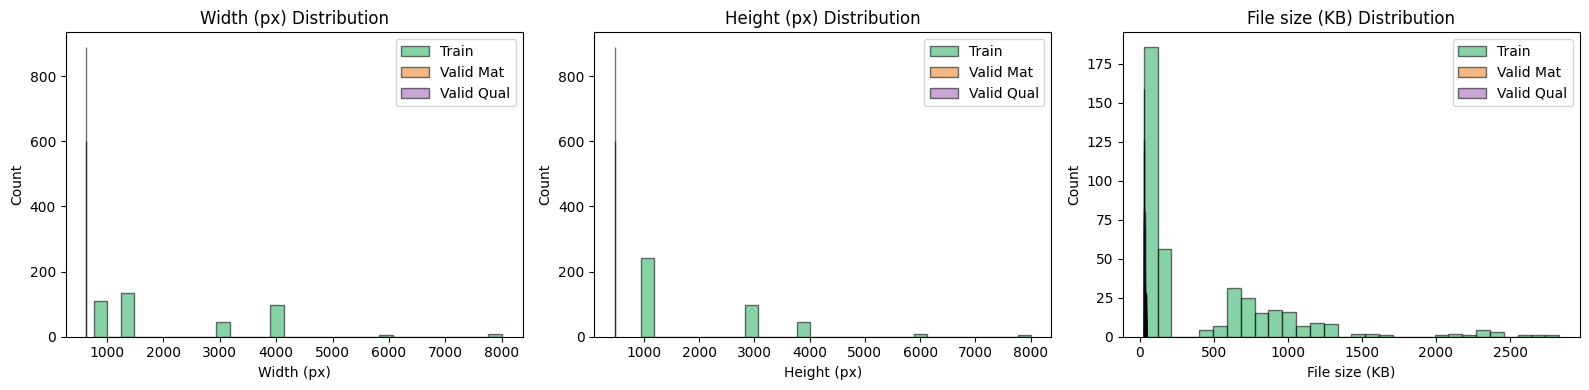

In [6]:
# 해상도 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, prop, label in zip(axes, ['width', 'height', 'size_kb'], ['Width (px)', 'Height (px)', 'File size (KB)']):
    ax.hist(train_meta[prop].dropna(),    bins=30, alpha=0.55, label='Train', color='#27ae60', edgecolor='black')
    ax.hist(val_mat_meta[prop].dropna(),  bins=30, alpha=0.55, label='Valid Mat',  color='#e67e22', edgecolor='black')
    ax.hist(val_qual_meta[prop].dropna(), bins=30, alpha=0.55, label='Valid Qual', color='#9b59b6', edgecolor='black')
    ax.set_xlabel(label); ax.set_ylabel('Count'); ax.set_title(f'{label} Distribution')
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / '11_train_vs_valid_image_properties.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Train vs Valid 비교: RGB 색상 통계

도메인 갭이 있는지 정량 확인. (학습에서 본 색 분포와 평가에서 마주칠 색 분포가 비슷한지?)

In [7]:
def compute_rgb(filepath):
    try:
        # 한글 경로 대응
        img_arr = np.fromfile(str(filepath), dtype=np.uint8)
        img = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
        if img is None:
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()
    except Exception:
        return None

def sample_rgb(df, n_per_class=80):
    records = []
    for (task, cls), g in df.groupby(['task', 'class_label']):
        sub = g.sample(n=min(n_per_class, len(g)), random_state=SEED)
        for _, r in tqdm(sub.iterrows(), total=len(sub), desc=f'{task}/{cls}', leave=False):
            v = compute_rgb(r['filepath'])
            if v:
                records.append({'task': task, 'class_label': cls, 'R': v[0], 'G': v[1], 'B': v[2]})
    return pd.DataFrame(records)

print('Train RGB 분석 (각 클래스 80장 샘플) ...')
train_rgb = sample_rgb(train_aligned, n_per_class=80)
print('Valid Maturity RGB ...')
val_mat_rgb = sample_rgb(val_mat_aligned, n_per_class=80)
print('Valid Quality RGB ...')
val_qual_rgb = sample_rgb(val_qual_aligned, n_per_class=80)

# 통합 비교 표
def rgb_table(df, split):
    g = df.groupby(['task', 'class_label'])[['R','G','B']].mean().round(1)
    g['split'] = split
    return g.reset_index()

combined = pd.concat([
    rgb_table(train_rgb,    'train'),
    rgb_table(val_mat_rgb,  'valid'),
    rgb_table(val_qual_rgb, 'valid'),
], ignore_index=True)

# pivot: (task, class) × (split: train/valid) → R, G, B
print('\n=== Train vs Valid RGB 평균 ===')
pivot = combined.pivot_table(index=['task', 'class_label'], columns='split',
                              values=['R', 'G', 'B']).round(1)
print(pivot)
pivot.to_csv(TABLES_DIR / '05_train_vs_valid_rgb.csv')

Train RGB 분석 (각 클래스 80장 샘플) ...


maturity/immature:   0%|          | 0/80 [00:00<?, ?it/s]

maturity/mature:   0%|          | 0/80 [00:00<?, ?it/s]

quality/fresh:   0%|          | 0/80 [00:00<?, ?it/s]

quality/rotten:   0%|          | 0/80 [00:00<?, ?it/s]

...

maturity/mature:   0%|          | 0/80 [00:00<?, ?it/s]

Valid Quality RGB ...


quality/fresh:   0%|          | 0/80 [00:00<?, ?it/s]

quality/rotten:   0%|          | 0/80 [00:00<?, ?it/s]


=== Train vs Valid RGB 평균 ===
                          B            G            R      
split                 train valid  train valid  train valid
task     class_label                                       
maturity immature      81.1  72.0  124.3  78.3  120.7  86.7
         mature        61.5  74.9  110.7  77.7  120.9  89.8
quality  fresh        129.6  73.1  140.2  76.4  173.6  89.0
         rotten       130.1  78.4  139.1  80.9  168.9  92.4


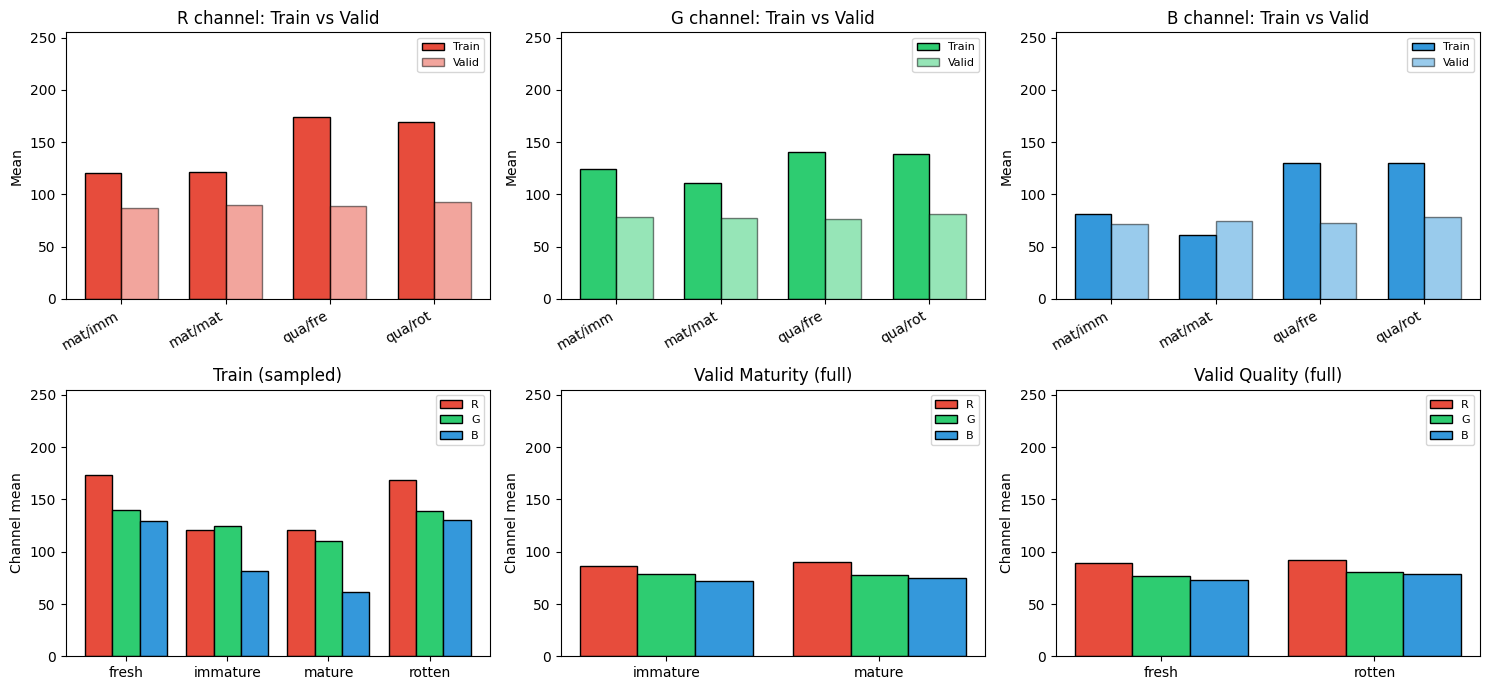

In [8]:
# RGB 차이 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
combos = [('maturity', 'immature'), ('maturity', 'mature'),
          ('quality', 'fresh'),    ('quality', 'rotten')]

# 첫 행: train vs valid 각 채널 평균 비교
ax_row1 = axes[0]
for ax_idx, (channel, color) in enumerate(zip(['R','G','B'], ['#e74c3c','#2ecc71','#3498db'])):
    ax = ax_row1[ax_idx]
    labels, t_vals, v_vals = [], [], []
    for task, cls in combos:
        labels.append(f'{task[:3]}/{cls[:3]}')
        t_vals.append(train_rgb[(train_rgb.task==task)&(train_rgb.class_label==cls)][channel].mean())
        valid_src = val_mat_rgb if task=='maturity' else val_qual_rgb
        v_vals.append(valid_src[(valid_src.task==task)&(valid_src.class_label==cls)][channel].mean())

    x = np.arange(len(labels)); width = 0.35
    ax.bar(x - width/2, t_vals, width, color=color, label='Train', edgecolor='black')
    ax.bar(x + width/2, v_vals, width, color=color, label='Valid', edgecolor='black', alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_title(f'{channel} channel: Train vs Valid')
    ax.set_ylabel('Mean'); ax.set_ylim(0, 255); ax.legend(fontsize=8)

# 두 번째 행: train, valid 각각 클래스 간 RGB 평균
ax_row2 = axes[1]
for ax, (df_src, title, color_palette) in zip(
    ax_row2,
    [(train_rgb, 'Train (sampled)',          ['#16a085','#27ae60','#2980b9','#3498db']),
     (val_mat_rgb,'Valid Maturity (full)',    ['#e67e22','#d35400','','']),
     (val_qual_rgb,'Valid Quality (full)',    ['','','#9b59b6','#8e44ad'])]):
    if df_src.empty: continue
    grp = df_src.groupby('class_label')[['R','G','B']].mean()
    x_pos = np.arange(len(grp))
    width = 0.27
    ax.bar(x_pos - width, grp['R'], width, color='#e74c3c', label='R', edgecolor='black')
    ax.bar(x_pos,         grp['G'], width, color='#2ecc71', label='G', edgecolor='black')
    ax.bar(x_pos + width, grp['B'], width, color='#3498db', label='B', edgecolor='black')
    ax.set_xticks(x_pos); ax.set_xticklabels(grp.index)
    ax.set_title(title); ax.set_ylabel('Channel mean'); ax.set_ylim(0, 255)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / '12_rgb_train_vs_valid.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 도메인 갭 자동 평가

각 (task, class)에 대해 Train과 Valid의 RGB 평균 차이를 측정. 큰 차이는 domain shift를 시사.

In [9]:
rows = []
for task, cls in combos:
    t = train_rgb[(train_rgb.task==task)&(train_rgb.class_label==cls)]
    valid_src = val_mat_rgb if task=='maturity' else val_qual_rgb
    v = valid_src[(valid_src.task==task)&(valid_src.class_label==cls)]
    if t.empty or v.empty: continue
    rows.append({
        'task': task, 'class': cls,
        'train_R': t.R.mean(), 'valid_R': v.R.mean(), 'ΔR': v.R.mean() - t.R.mean(),
        'train_G': t.G.mean(), 'valid_G': v.G.mean(), 'ΔG': v.G.mean() - t.G.mean(),
        'train_B': t.B.mean(), 'valid_B': v.B.mean(), 'ΔB': v.B.mean() - t.B.mean(),
    })
gap = pd.DataFrame(rows).round(1)
print(gap.to_string(index=False))
gap.to_csv(TABLES_DIR / '06_train_vs_valid_rgb_gap.csv', index=False)

# 평균 절대 차이로 갭 정량화
mean_abs_gap = gap[['ΔR','ΔG','ΔB']].abs().mean().mean()
print(f'\n전체 평균 절대 RGB gap: {mean_abs_gap:.1f}')
if mean_abs_gap < 10:
    print('✅ 도메인 갭 작음 — train/valid 색 분포 유사')
elif mean_abs_gap < 20:
    print('⚠️ 중간 정도 도메인 갭 — 보고 시 명시 필요')
else:
    print('🚨 큰 도메인 갭 — 일반화 성능에 영향 가능')

    task    class  train_R  valid_R    ΔR  train_G  valid_G    ΔG  train_B  valid_B    ΔB
maturity immature    120.7     86.7 -34.0    124.3     78.3 -45.9     81.1     72.0  -9.1
maturity   mature    120.9     89.8 -31.2    110.7     77.7 -33.0     61.5     74.9  13.4
 quality    fresh    173.6     89.0 -84.6    140.2     76.4 -63.8    129.6     73.1 -56.5
 quality   rotten    168.9     92.4 -76.5    139.1     80.9 -58.2    130.1     78.4 -51.7

전체 평균 절대 RGB gap: 46.5
🚨 큰 도메인 갭 — 일반화 성능에 영향 가능


## 8. 샘플 시각화: Train vs Valid

각 (task, class) × (split) 별로 1장씩 보여 도메인 차이를 시각적으로 확인.

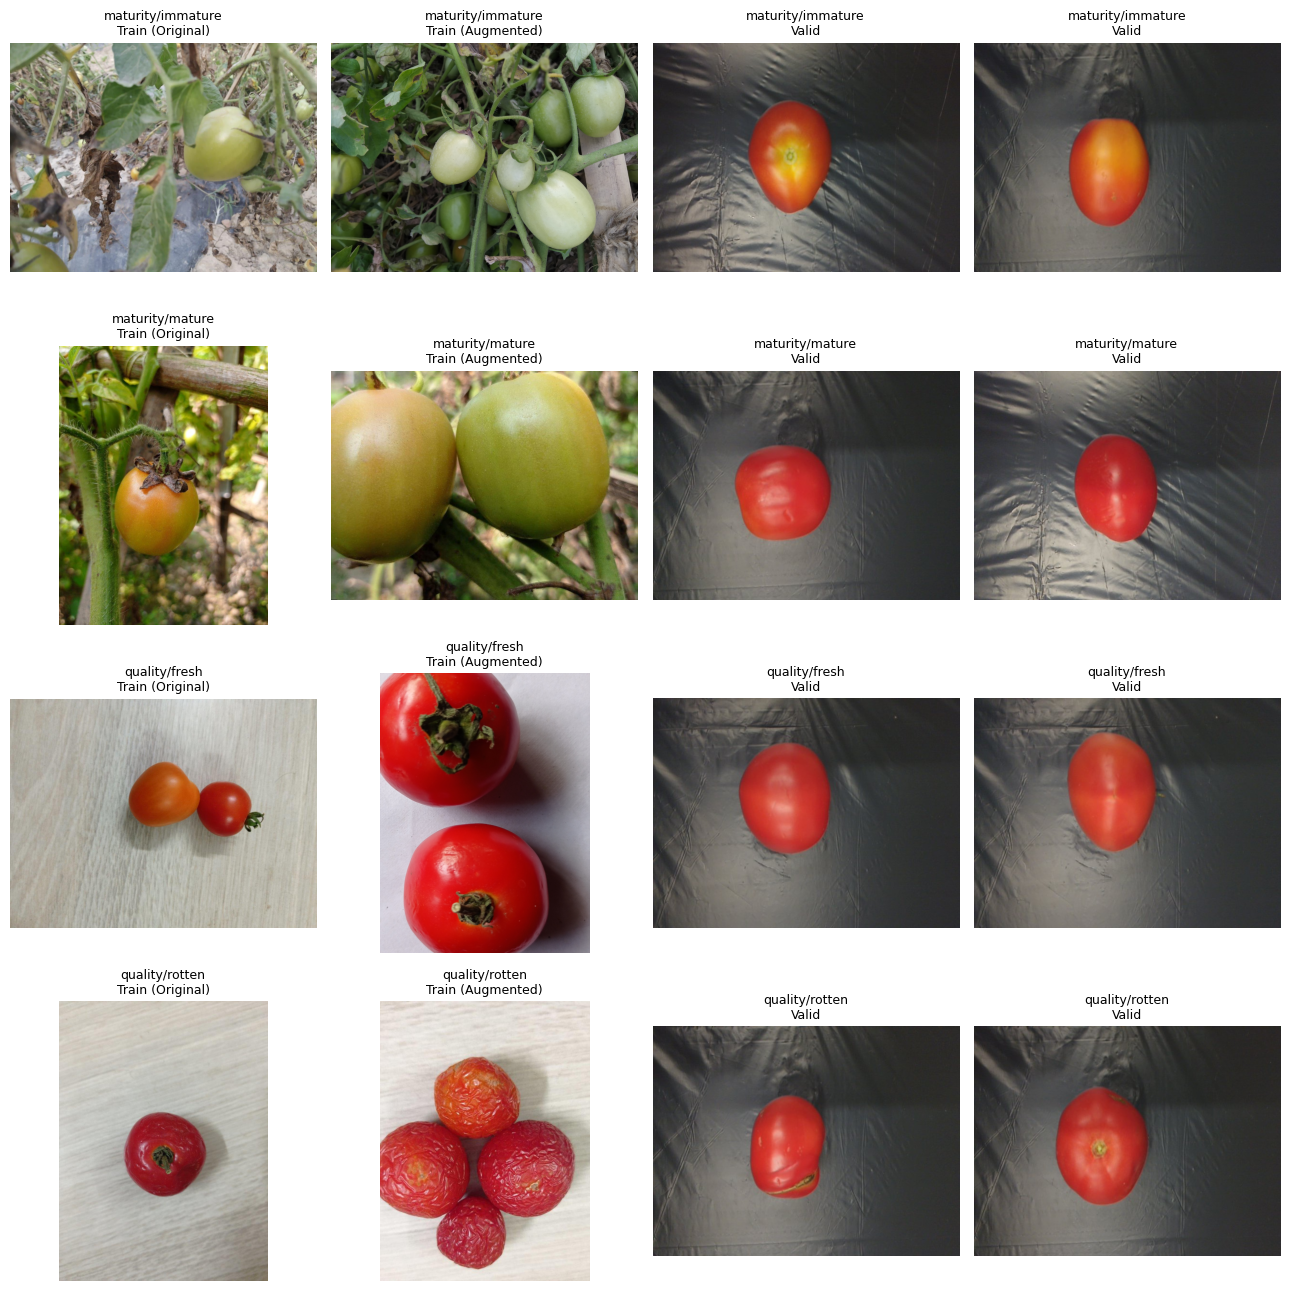

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
combos_full = [('maturity', 'immature'), ('maturity', 'mature'),
               ('quality', 'fresh'),    ('quality', 'rotten')]

for row, (task, cls) in enumerate(combos_full):
    # Train original
    src = train_aligned[(train_aligned.task==task)&(train_aligned.class_label==cls)&(train_aligned.dataset_type=='original')]
    s = src.sample(1, random_state=SEED+row).iloc[0]
    img = Image.open(s['filepath']).convert('RGB')
    axes[row, 0].imshow(img); axes[row, 0].set_title(f'{task}/{cls}\nTrain (Original)', fontsize=9); axes[row, 0].axis('off')

    # Train augmented
    src = train_aligned[(train_aligned.task==task)&(train_aligned.class_label==cls)&(train_aligned.dataset_type=='augment')]
    s = src.sample(1, random_state=SEED+row).iloc[0]
    img = Image.open(s['filepath']).convert('RGB')
    axes[row, 1].imshow(img); axes[row, 1].set_title(f'{task}/{cls}\nTrain (Augmented)', fontsize=9); axes[row, 1].axis('off')

    # Valid (2장)
    valid_src = val_mat_aligned if task=='maturity' else val_qual_aligned
    src = valid_src[valid_src.class_label==cls]
    for j, col in enumerate([2, 3]):
        s = src.sample(1, random_state=SEED+row+j).iloc[0]
        img = Image.open(s['filepath']).convert('RGB')
        axes[row, col].imshow(img); axes[row, col].set_title(f'{task}/{cls}\nValid', fontsize=9); axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '13_train_vs_valid_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. GPU 서버용 패키지 생성

이미지 파일을 `package/images/` 아래로 복사하고, CSV의 `filepath`를 패키지 상대 경로로 갱신.

In [11]:
# 1) 기존 패키지가 있으면 삭제하고 새로 만들기
if PACKAGE_DIR.exists():
    print(f'기존 {PACKAGE_DIR} 삭제 중...')
    shutil.rmtree(PACKAGE_DIR)
PACKAGE_DIR.mkdir(parents=True)
(PACKAGE_DIR / 'images').mkdir()
(PACKAGE_DIR / 'images' / 'train').mkdir()
(PACKAGE_DIR / 'images' / 'valid').mkdir()
(PACKAGE_DIR / 'manifest').mkdir()

print(f'✅ 패키지 디렉토리 생성: {PACKAGE_DIR}')

✅ 패키지 디렉토리 생성: C:\Users\smin\IdeaProjects\tomato\package


In [12]:
# 2) Train 이미지 복사 — 학습 폴더 구조 보존
print('Train 이미지 복사 중 (10,000장)...')
train_paths = []
for _, row in tqdm(train_aligned.iterrows(), total=len(train_aligned), desc='train'):
    src = Path(row['filepath'])
    # 상대 경로: train/{task}/{dataset_type}/{class_label}/{filename}
    rel_dir = Path('images') / 'train' / row['task'] / row['dataset_type'] / row['class_label']
    (PACKAGE_DIR / rel_dir).mkdir(parents=True, exist_ok=True)
    dst = PACKAGE_DIR / rel_dir / row['filename']
    if not dst.exists():
        shutil.copy2(src, dst)
    train_paths.append(str(rel_dir / row['filename']).replace('\\', '/'))

train_aligned['filepath'] = train_paths
print(f'✅ Train 복사 완료: {len(train_paths)} 장')

Train 이미지 복사 중 (10,000장)...


train:   0%|          | 0/10000 [00:00<?, ?it/s]

✅ Train 복사 완료: 10000 장


In [13]:
# 3) Valid 이미지 복사 — hash 기반 중복 제거 (maturity와 quality가 공유 가능)
print('Valid 이미지 복사 중 (unique by content_hash)...')

# 두 valid 합쳐서 unique hash 추출
all_valid = pd.concat([val_mat_aligned, val_qual_aligned], ignore_index=True)
unique_by_hash = all_valid.drop_duplicates(subset='content_hash', keep='first')

hash_to_relpath = {}
for _, row in tqdm(unique_by_hash.iterrows(), total=len(unique_by_hash), desc='valid'):
    src = Path(row['filepath'])
    # 새 파일명: hash 앞 8자 + 원본 파일명 (충돌 방지)
    h = (row['content_hash'] or 'nohash')[:8]
    new_name = f'{h}_{row["filename"]}'
    rel_path = Path('images') / 'valid' / new_name
    dst = PACKAGE_DIR / rel_path
    if not dst.exists():
        shutil.copy2(src, dst)
    hash_to_relpath[row['content_hash']] = str(rel_path).replace('\\', '/')

# val_mat, val_qual의 filepath를 새 상대경로로 매핑
val_mat_aligned['filepath']  = val_mat_aligned['content_hash'].map(hash_to_relpath)
val_qual_aligned['filepath'] = val_qual_aligned['content_hash'].map(hash_to_relpath)

print(f'✅ Valid 복사 완료: {len(hash_to_relpath)} unique 이미지')
print(f'   val_maturity 행수:  {len(val_mat_aligned)}  (NaN filepath: {val_mat_aligned.filepath.isna().sum()})')
print(f'   val_quality 행수:   {len(val_qual_aligned)} (NaN filepath: {val_qual_aligned.filepath.isna().sum()})')

Valid 이미지 복사 중 (unique by content_hash)...


valid:   0%|          | 0/1556 [00:00<?, ?it/s]

✅ Valid 복사 완료: 1556 unique 이미지
   val_maturity 행수:  890  (NaN filepath: 0)
   val_quality 행수:   1556 (NaN filepath: 0)


In [14]:
# 4) Manifest CSV 저장
train_aligned.to_csv(PACKAGE_DIR / 'manifest' / 'train.csv', index=False)
val_mat_aligned.to_csv(PACKAGE_DIR / 'manifest' / 'valid_maturity.csv', index=False)
val_qual_aligned.to_csv(PACKAGE_DIR / 'manifest' / 'valid_quality.csv', index=False)

print('✅ Manifest 저장 완료')
for n in ['train.csv', 'valid_maturity.csv', 'valid_quality.csv']:
    p = PACKAGE_DIR / 'manifest' / n
    print(f'  {n}: {p.stat().st_size:,} bytes')

✅ Manifest 저장 완료
  train.csv: 2,378,931 bytes
  valid_maturity.csv: 136,836 bytes
  valid_quality.csv: 234,032 bytes


In [15]:
# 5) meta.json — 패키지 메타정보
meta = {
    'package_version': '1.0',
    'created_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
    'description': 'Tomato MTL dataset package — train (matched subsampling) + external valid (dedup + label mapped)',

    'train': {
        'total': int(len(train_aligned)),
        'by_task_class': {f'{k[0]}/{k[1]}': int(v) for k, v in train_aligned.groupby(['task','class_label']).size().to_dict().items()},
        'by_dataset_type': train_aligned['dataset_type'].value_counts().to_dict(),
        'strategy': 'Option X: 500 original + 2000 augmented per class, structure-matched across tasks',
    },

    'valid_maturity': {
        'total': int(len(val_mat_aligned)),
        'by_class': val_mat_aligned['class_label'].value_counts().to_dict(),
    },
    'valid_quality': {
        'total': int(len(val_qual_aligned)),
        'by_class': val_qual_aligned['class_label'].value_counts().to_dict(),
    },

    'valid_unique_images': len(hash_to_relpath),

    'rgb_gap': {
        'mean_abs_gap': float(mean_abs_gap),
        'interpretation': 'small' if mean_abs_gap<10 else ('medium' if mean_abs_gap<20 else 'large'),
    },

    'preprocessing_for_training': {
        'input_size': [224, 224],
        'normalization': 'ImageNet mean/std',
        'augmentation_at_train': ['HFlip', 'Rotation±15°', 'ColorJitter', 'RandomResizedCrop'],
        'augmentation_at_eval': 'None (TTA optional)',
    },

    'notes': [
        'train 데이터는 원본 + 증강 이미 매칭됨; 학습 시 추가 증강은 가벼운 강도 권장',
        'valid는 학습에 사용 금지 (외부 검증 전용)',
        'Maturity Immature 클래스는 unique 93장 → bootstrap CI 보고 권장',
        'filepath 컬럼은 모두 patch root 기준 상대 경로 (예: images/train/maturity/original/immature/foo.jpg)',
    ],
}

(PACKAGE_DIR / 'meta.json').write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')
print('✅ meta.json 저장')
print(json.dumps(meta, indent=2, ensure_ascii=False))

✅ meta.json 저장
{
  "package_version": "1.0",
  "created_date": "2026-05-15 11:22",
  "description": "Tomato MTL dataset package — train (matched subsampling) + external valid (dedup + label mapped)",
  "train": {
    "total": 10000,
    "by_task_class": {
      "maturity/immature": 2500,
      "maturity/mature": 2500,
      "quality/fresh": 2500,
      "quality/rotten": 2500
    },
    "by_dataset_type": {
      "augment": 8000,
      "original": 2000
    },
    "strategy": "Option X: 500 original + 2000 augmented per class, structure-matched across tasks"
  },
  "valid_maturity": {
    "total": 890,
    "by_class": {
      "mature": 797,
      "immature": 93
    }
  },
  "valid_quality": {
    "total": 1556,
    "by_class": {
      "fresh": 890,
      "rotten": 666
    }
  },
  "valid_unique_images": 1556,
  "rgb_gap": {
    "mean_abs_gap": 46.49166666666667,
    "interpretation": "large"
  },
  "preprocessing_for_training": {
    "input_size": [
      224,
      224
    ],
    "norma

In [16]:
# 6) README.md — GPU 서버에서 사용 안내
readme = '''# Tomato MTL Dataset Package

## 개요
- 학습 데이터: 10,000장 (Maturity 5,000 + Quality 5,000, Option X 매칭)
- 외부 검증: Maturity 890장 + Quality 1,556장 (고유 1,559장)

## 사용법 (PyTorch)
```python
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image

PKG = Path("/path/to/this/package")
train = pd.read_csv(PKG / "manifest" / "train.csv")
val_m = pd.read_csv(PKG / "manifest" / "valid_maturity.csv")
val_q = pd.read_csv(PKG / "manifest" / "valid_quality.csv")

class TomatoDataset(Dataset):
    def __init__(self, df, pkg_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.pkg = Path(pkg_root)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.pkg / row["filepath"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, row["task"], row["class_label"]
```

## 파일 구조
- `images/train/{task}/{type}/{class}/`: 학습 이미지
- `images/valid/`: 외부 검증 이미지 (hash 접두사로 명명)
- `manifest/*.csv`: 학습/평가용 CSV
- `meta.json`: 데이터셋 메타정보

## 컬럼 스키마 (모든 CSV 동일)
- `filepath`: 패키지 루트 기준 상대 경로
- `task`: maturity / quality
- `dataset_type`: original / augment / external_valid
- `class_label`: immature / mature / fresh / rotten
- `filename`: 원본 파일명
- `is_augmented`: True/False
- `original_basename`: 원본 추적용 group key
- `split`: train / valid
- `content_hash`: MD5 (valid만)

## 주의사항
- Maturity Immature 클래스는 valid에서 93장만 unique → bootstrap CI 권장
- 학습 데이터는 이미 증강 포함; 추가 증강은 보수적으로
'''
(PACKAGE_DIR / 'README.md').write_text(readme, encoding='utf-8')
print('✅ README.md 저장')

✅ README.md 저장


## 10. 패키지 검증

In [17]:
# 파일 수 검증
def count_files(d):
    return sum(1 for _ in d.rglob('*') if _.is_file())

train_imgs = count_files(PACKAGE_DIR / 'images' / 'train')
valid_imgs = count_files(PACKAGE_DIR / 'images' / 'valid')
manifest_files = count_files(PACKAGE_DIR / 'manifest')

print('=== 패키지 검증 ===')
print(f'images/train/*  : {train_imgs:>6,} files  (expected 10,000)')
print(f'images/valid/*  : {valid_imgs:>6,} files  (expected {len(hash_to_relpath):,})')
print(f'manifest/*      : {manifest_files:>6,} files  (expected 3)')

# 패키지 총 크기
total_size = sum(p.stat().st_size for p in PACKAGE_DIR.rglob('*') if p.is_file())
print(f'\n총 패키지 크기: {total_size/1024/1024:.1f} MB')

# CSV 로드 테스트
df_check = pd.read_csv(PACKAGE_DIR / 'manifest' / 'train.csv')
print(f'\ntrain.csv load: {len(df_check)} rows  columns={list(df_check.columns)}')
print(f'첫 행 filepath 예시: {df_check.iloc[0].filepath}')

# 실제 파일 존재 검증 (랜덤 100개)
sample = df_check.sample(100, random_state=SEED)
missing = sum(1 for fp in sample['filepath'] if not (PACKAGE_DIR / fp).exists())
print(f'\n샘플 100개 중 누락: {missing}')
assert missing == 0, '일부 파일 누락'
print('✅ 모든 샘플 파일 존재')

=== 패키지 검증 ===


images/train/*  : 10,000 files  (expected 10,000)
images/valid/*  :  1,556 files  (expected 1,556)
manifest/*      :      3 files  (expected 3)



총 패키지 크기: 4344.4 MB

train.csv load: 10000 rows  columns=['filepath', 'task', 'dataset_type', 'class_label', 'filename', 'is_augmented', 'original_basename', 'split', 'content_hash']
첫 행 filepath 예시: images/train/maturity/original/immature/IMG_20230309_160200.jpg

샘플 100개 중 누락: 0
✅ 모든 샘플 파일 존재


## 11. (선택) Zip 압축 — GPU 서버로 전송

In [18]:
# zip 압축 (큰 데이터셋의 경우 시간이 좀 걸림)
zip_path = PROJECT_ROOT / 'package.zip'

import zipfile
print(f'압축 중 → {zip_path}')

with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    for f in tqdm(list(PACKAGE_DIR.rglob('*')), desc='zip'):
        if f.is_file():
            zf.write(f, arcname=f.relative_to(PACKAGE_DIR.parent))

print(f'\n✅ 압축 완료: {zip_path}')
print(f'   원본:  {total_size/1024/1024:.1f} MB')
print(f'   압축: {zip_path.stat().st_size/1024/1024:.1f} MB')

압축 중 → C:\Users\smin\IdeaProjects\tomato\package.zip


zip:   0%|          | 0/11579 [00:00<?, ?it/s]


✅ 압축 완료: C:\Users\smin\IdeaProjects\tomato\package.zip
   원본:  4344.4 MB
   압축: 4265.6 MB


## 12. 요약

### 산출물
- `package/` 디렉토리 — GPU 서버로 옮길 자기완결적 데이터셋
- `package.zip` — 압축본 (서버 전송용)

### 다음 단계 (GPU 서버에서)
1. `package.zip`을 GPU 서버에 업로드
2. 압축 해제: `unzip package.zip`
3. `manifest/*.csv` 로드해서 PyTorch Dataset 구축
4. 학습 시작 (Phase 1: ResNet50 메인)

### 비교 분석 산출 (논문에 활용)
- `results/figures/10_train_vs_valid_distribution.png`
- `results/figures/11_train_vs_valid_image_properties.png`
- `results/figures/12_rgb_train_vs_valid.png`
- `results/figures/13_train_vs_valid_samples.png`
- `results/tables/05_train_vs_valid_rgb.csv`
- `results/tables/06_train_vs_valid_rgb_gap.csv`